In [33]:
import pandas as pd
import json

In [34]:
#load csv
df = pd.read_csv("./data/dreps_data.csv")
len(df)

931

In [35]:
df.columns

Index(['hash', 'bech32_legacy', 'has_script', 'tx_hash', 'url', 'comment',
       'payment_address', 'given_name', 'objectives', 'motivations',
       'qualifications', 'image', 'live_stake', 'delegator', 'tx_time',
       'last_active_epoch', 'bech32'],
      dtype='object')

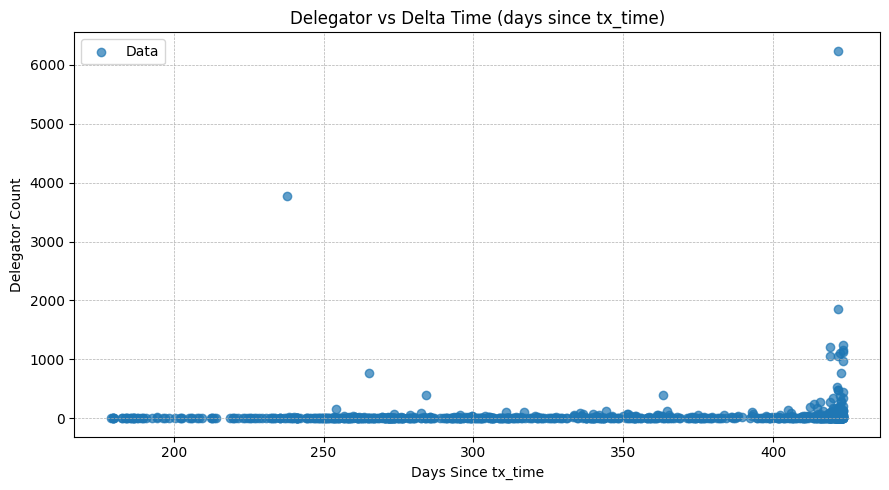

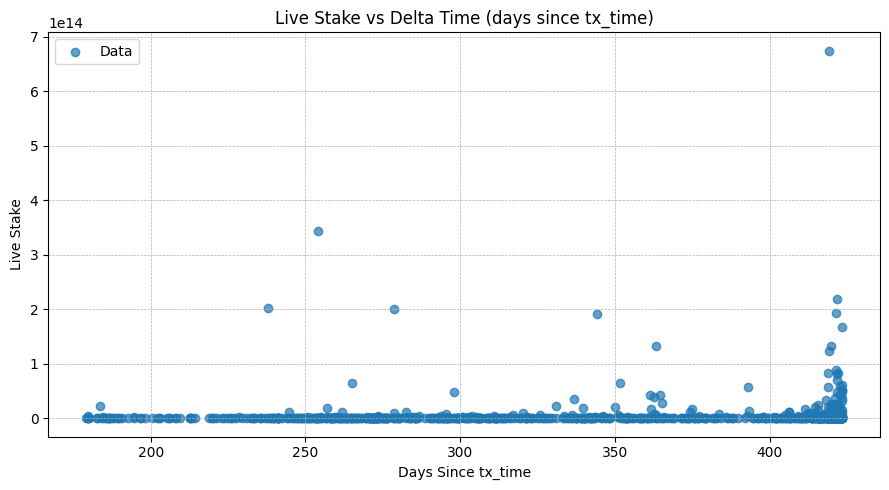

In [40]:
from datetime import datetime, timezone
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === COMPUTE DELTA TIME (days from tx_time to now) ===
now = datetime.now(timezone.utc)
df["tx_time"] = pd.to_numeric(df["tx_time"], errors="coerce")
df["delegator"] = pd.to_numeric(df["delegator"], errors="coerce")
df["live_stake"] = pd.to_numeric(df["live_stake"], errors="coerce")

df = df.dropna(subset=["tx_time", "delegator", "live_stake"])
df["delta_days"] = (now - pd.to_datetime(df["tx_time"], unit="s", utc=True)).dt.total_seconds() / (24 * 3600)

# === PLOT 1: Delegator vs Delta Time ===
plt.figure(figsize=(9, 5))
plt.scatter(df["delta_days"], df["delegator"], marker="o", alpha=0.7, label="Data")



plt.title("Delegator vs Delta Time (days since tx_time)")
plt.xlabel("Days Since tx_time")
plt.ylabel("Delegator Count")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

# === PLOT 2: Live Stake vs Delta Time ===
plt.figure(figsize=(9, 5))
plt.scatter(df["delta_days"], df["live_stake"], marker="o", alpha=0.7, label="Data")



plt.title("Live Stake vs Delta Time (days since tx_time)")
plt.xlabel("Days Since tx_time")
plt.ylabel("Live Stake")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


Top 10% delegator count starts at: 57
Top 10% live stake starts at: 7,091,227,319,188


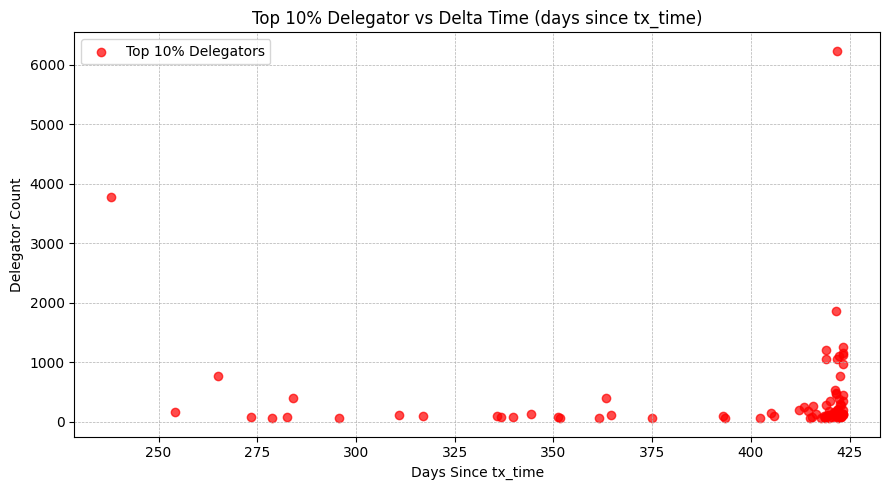

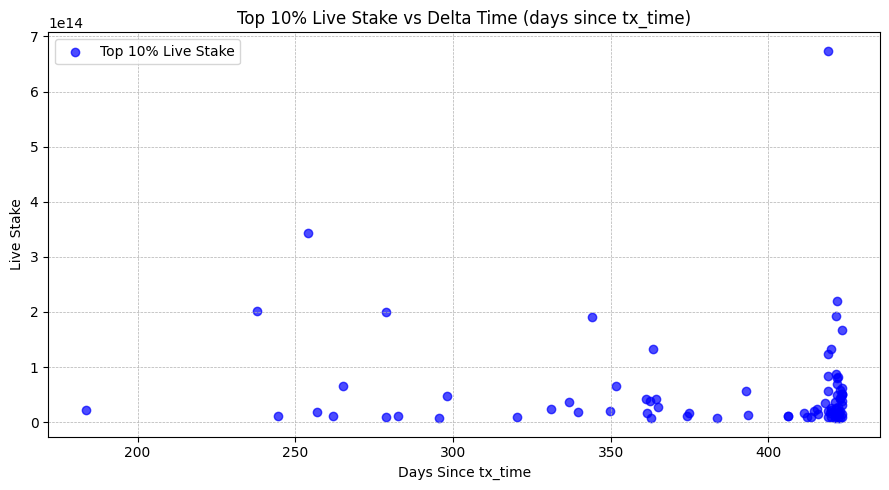

In [41]:
import matplotlib.pyplot as plt

# === CALCULATE TOP 10% THRESHOLDS ===
# The top 10% are values greater than or equal to the 90th percentile (quantile=0.9)
delegator_threshold = df["delegator"].quantile(0.9)
live_stake_threshold = df["live_stake"].quantile(0.9)

print(f"Top 10% delegator count starts at: {delegator_threshold:,.0f}")
print(f"Top 10% live stake starts at: {live_stake_threshold:,.0f}")

# === FILTER DATAFRAMES ===
df_top_delegator = df[df["delegator"] >= delegator_threshold]
df_top_live_stake = df[df["live_stake"] >= live_stake_threshold]

# === PLOT 1: Top 10% Delegator vs Delta Time ===
plt.figure(figsize=(9, 5))
plt.scatter(df_top_delegator["delta_days"], df_top_delegator["delegator"], 
            marker="o", alpha=0.7, label="Top 10% Delegators", color="red")

plt.title("Top 10% Delegator vs Delta Time (days since tx_time)")
plt.xlabel("Days Since tx_time")
plt.ylabel("Delegator Count")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

# === PLOT 2: Top 10% Live Stake vs Delta Time ===
plt.figure(figsize=(9, 5))
plt.scatter(df_top_live_stake["delta_days"], df_top_live_stake["live_stake"], 
            marker="o", alpha=0.7, label="Top 10% Live Stake", color="blue")

plt.title("Top 10% Live Stake vs Delta Time (days since tx_time)")
plt.xlabel("Days Since tx_time")
plt.ylabel("Live Stake")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

Original data points: 817
Data points over 400 days: 138


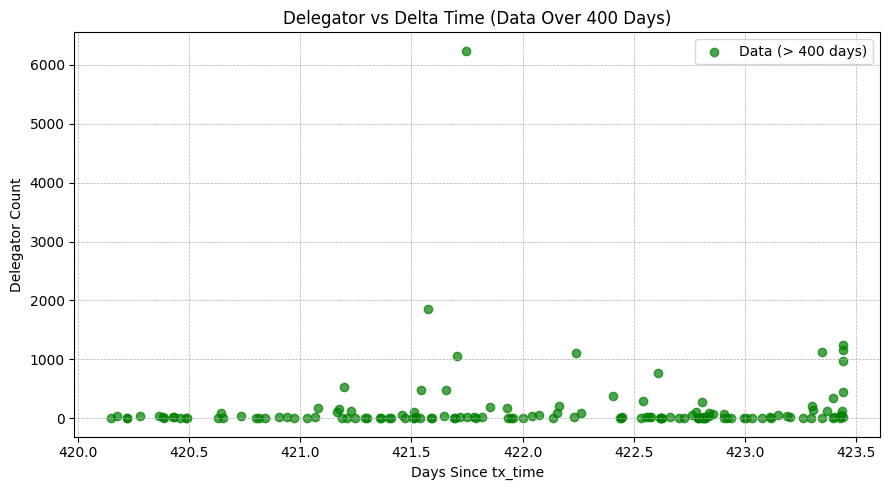

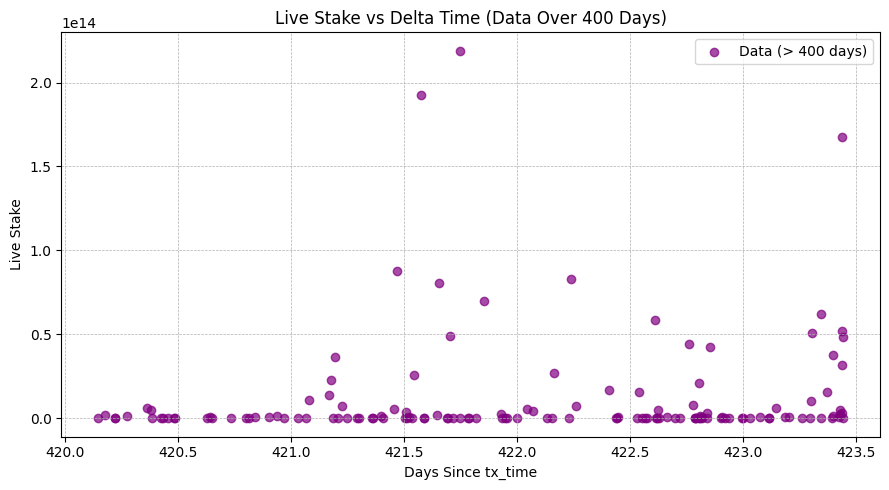

In [55]:
import matplotlib.pyplot as plt

# === FILTER DATA: Keep only data over 400 days ===
# Assumes 'df' with 'delta_days' column exists from a previous cell
df_over_400 = df[df["delta_days"] > 420].copy()

print(f"Original data points: {len(df)}")
print(f"Data points over 400 days: {len(df_over_400)}")

if len(df_over_400) > 0:
    # === PLOT 1: Delegator vs Delta Time (> 400 days) ===
    plt.figure(figsize=(9, 5))
    plt.scatter(df_over_400["delta_days"], df_over_400["delegator"], 
                marker="o", alpha=0.7, label="Data (> 400 days)", color="green")
    
    plt.title("Delegator vs Delta Time (Data Over 400 Days)")
    plt.xlabel("Days Since tx_time")
    plt.ylabel("Delegator Count")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()
    
    # === PLOT 2: Live Stake vs Delta Time (> 400 days) ===
    plt.figure(figsize=(9, 5))
    plt.scatter(df_over_400["delta_days"], df_over_400["live_stake"], 
                marker="o", alpha=0.7, label="Data (> 400 days)", color="purple")
    
    plt.title("Live Stake vs Delta Time (Data Over 400 Days)")
    plt.xlabel("Days Since tx_time")
    plt.ylabel("Live Stake")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No data found with delta_days > 400. No plots were generated.")